In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 1

### Questão 1
**Contexto:** fs = 20000 Hz. Filtros baseados em blocos de 2ª ordem.
Investigação dos efeitos do parâmetro $r$ (raio dos polos) na estabilidade e seletividade.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000
def plot_filter_analysis(b, a, r, title):
    w, h = signal.freqz(b, a, fs=fs)
    z, p, k = signal.tf2zpk(b, a)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Resposta em Frequência
    ax1.plot(w, 20 * np.log10(np.abs(h)))
    ax1.set_title(f'Resposta em Frequência - {title} (r={r})')
    ax1.set_xlabel('Frequência (Hz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.grid(True)

    # Polos e Zeros
    t = np.linspace(0, 2*np.pi, 100)
    ax2.plot(np.cos(t), np.sin(t), 'k--', alpha=0.5)
    ax2.scatter(np.real(z), np.imag(z), s=50, marker='o', facecolors='none', edgecolors='b', label='Zeros')
    ax2.scatter(np.real(p), np.imag(p), s=50, marker='x', color='r', label='Polos')
    ax2.set_title('Diagrama de Polos e Zeros')
    ax2.axis('equal')
    ax2.legend()
    ax2.grid(True)
    plt.show()

#### 1(a) Passa-baixas com fc = 1000 Hz

--- Análise para r = 0.7 ---


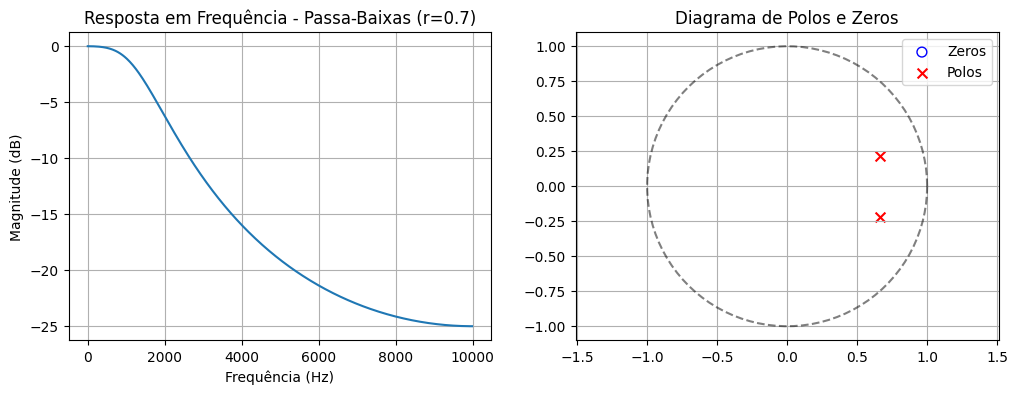

--- Análise para r = 0.9 ---


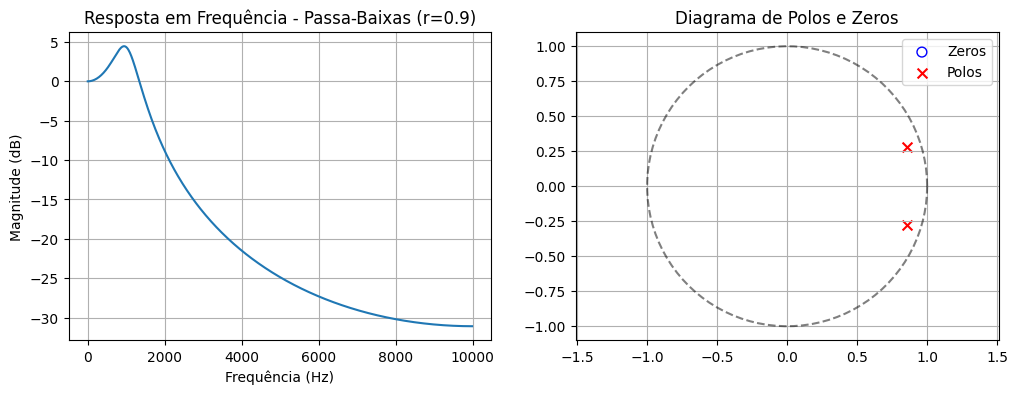

--- Análise para r = 0.99 ---


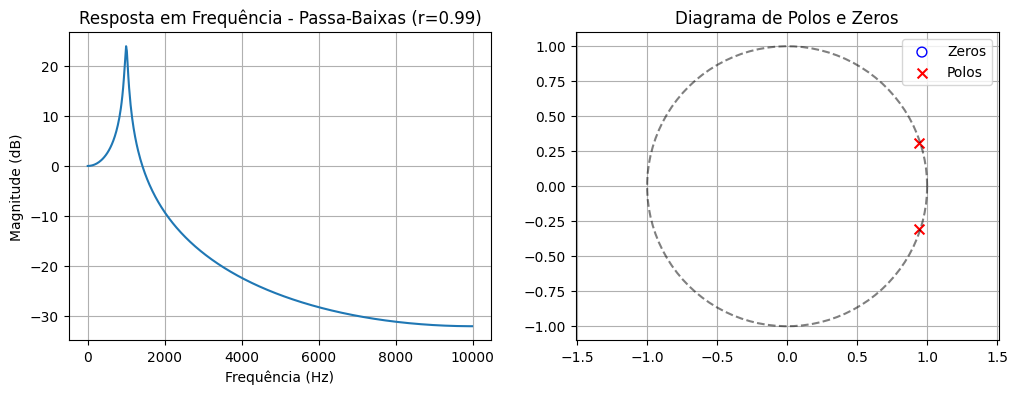

In [2]:
fc = 1000
theta = 2 * np.pi * fc / fs
for r in [0.7, 0.9, 0.99]:
    # H(z) = K / (1 - 2r cos(theta)z^-1 + r^2 z^-2)
    a = [1, -2 * r * np.cos(theta), r**2]
    b = [1 + r**2 - 2 * r * np.cos(theta)] # Ganho unitário em DC
    print(f'--- Análise para r = {r} ---')
    plot_filter_analysis(b, a, r, "Passa-Baixas")

**Comentários sobre os resultados (1a):**
- **Seletividade:** Conforme $r$ se aproxima de 1, o pico de ressonância na frequência de corte torna-se muito mais estreito e acentuado, aumentando a seletividade do filtro.
- **Estabilidade:** O sistema é estável para todos os valores testados, pois os polos estão dentro do círculo unitário ($r < 1$). No entanto, para $r=0.99$, o sistema está próximo da margem de instabilidade.
- **Largura de Banda:** A largura de banda diminui drasticamente com o aumento de $r$, estreitando a transição da banda de passagem.

#### 1(b) Passa-altas com fc = 2000 Hz

--- Análise para r = 0.7 ---


/tmp/ipykernel_6383/1859241358.py:13: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(w, 20 * np.log10(np.abs(h)))


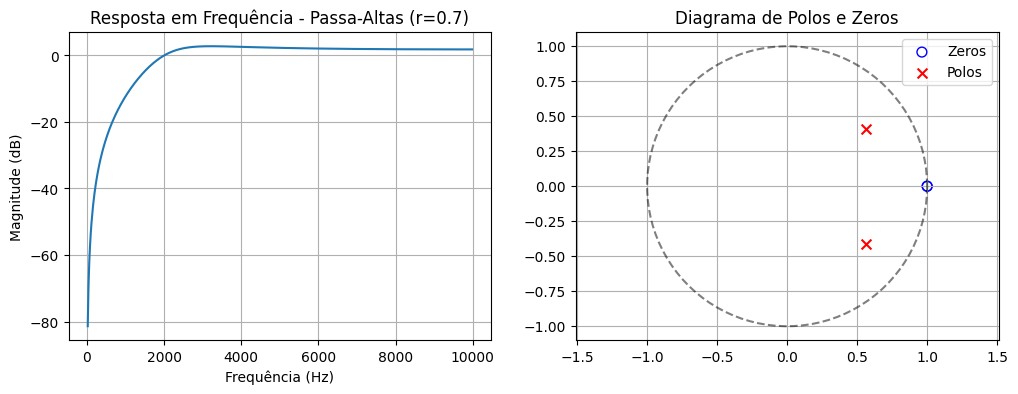

--- Análise para r = 0.9 ---


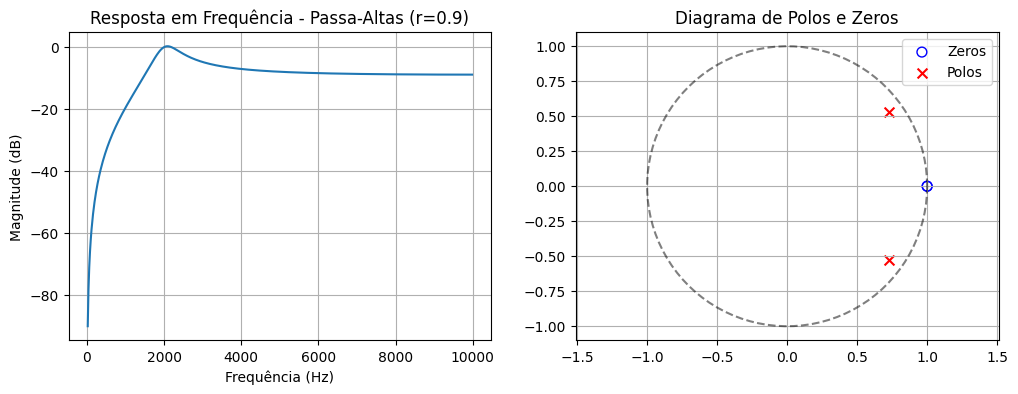

--- Análise para r = 0.99 ---


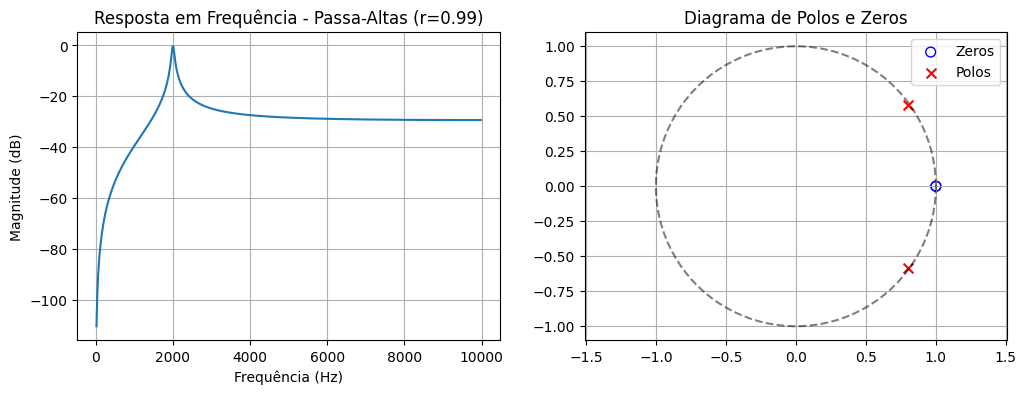

In [3]:
fc = 2000
theta = 2 * np.pi * fc / fs
for r in [0.7, 0.9, 0.99]:
    a = [1, -2 * r * np.cos(theta), r**2]
    # Zeros em z=1 para atenuar baixas frequências
    b = [1, -2, 1]
    # Normalização de ganho
    _, h_fc = signal.freqz(b, a, worN=[fc], fs=fs)
    b = b / np.abs(h_fc)
    print(f'--- Análise para r = {r} ---')
    plot_filter_analysis(b, a, r, "Passa-Altas")

**Comentários sobre os resultados (1b):**
- **Seletividade:** O filtro apresenta uma rejeição maior de frequências abaixo de 2000 Hz conforme $r$ aumenta.
- **Estabilidade:** Mantém-se estável, com polos migrando para a borda do círculo unitário à medida que $r \to 1$.
- **Largura de Banda:** O aumento de $r$ reduz a região de transição, tornando o filtro mais abrupto após a frequência de corte.

#### 1(c) Passa-faixas com fc = 7000 Hz

--- Análise para r = 0.8 ---


/tmp/ipykernel_6383/1859241358.py:13: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(w, 20 * np.log10(np.abs(h)))


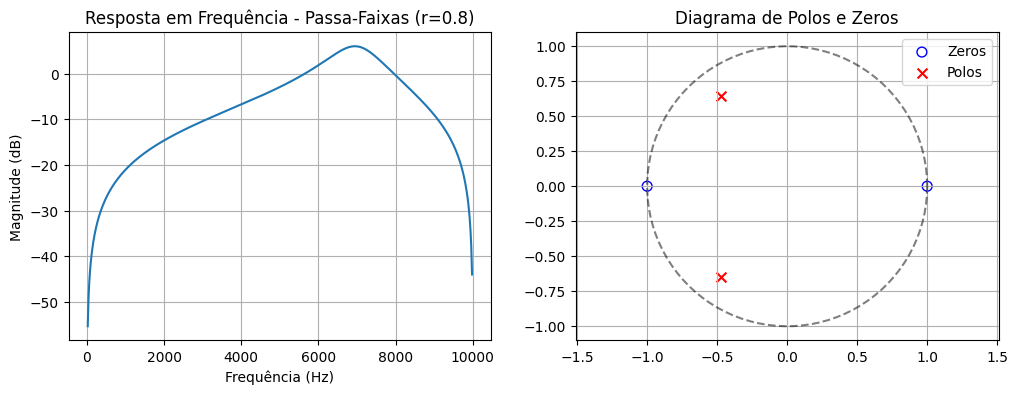

--- Análise para r = 0.9 ---


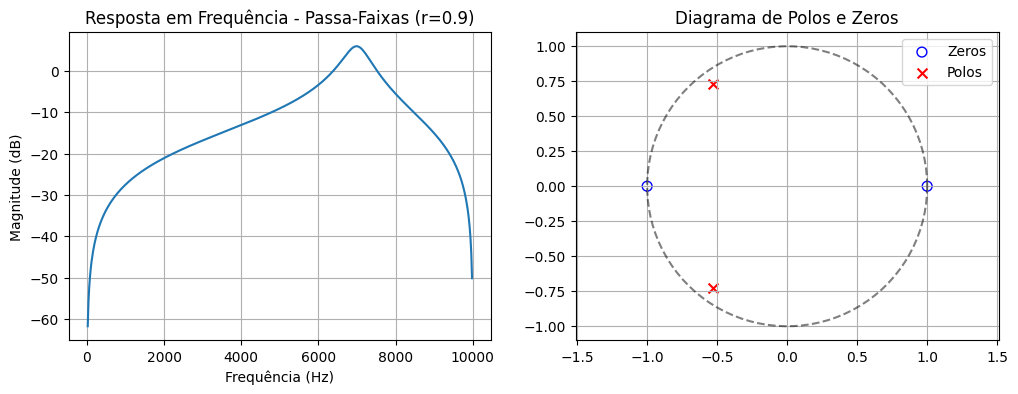

--- Análise para r = 0.98 ---


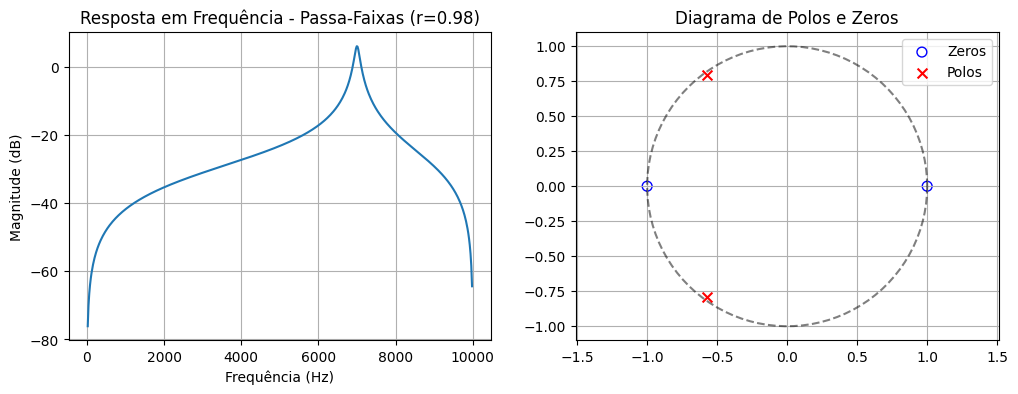

In [4]:
fc = 7000
theta = 2 * np.pi * fc / fs
for r in [0.8, 0.9, 0.98]:
    a = [1, -2 * r * np.cos(theta), r**2]
    b = [1 - r**2, 0, -(1 - r**2)] # Zeros em z=1 e z=-1
    print(f'--- Análise para r = {r} ---')
    plot_filter_analysis(b, a, r, "Passa-Faixas")

**Comentários sobre os resultados (1c):**
- **Seletividade:** A largura da banda de passagem é inversamente proporcional a $r$. Com $r=0.98$, temos um filtro de banda muito estreita (Q elevado).
- **Estabilidade:** Estável. A resposta temporal seria mais longa (maior ringing) para valores altos de $r$ devido à proximidade dos polos com o círculo unitário.
- **Largura de Banda:** Definida por $\Delta f \approx \frac{fs(1-r)}{\pi}$. Nota-se visualmente o estreitamento da banda central em 7kHz.

#### 1(d) Notch (Rejeita-faixa) com fc = 3000 Hz

--- Análise para r = 0.8 ---


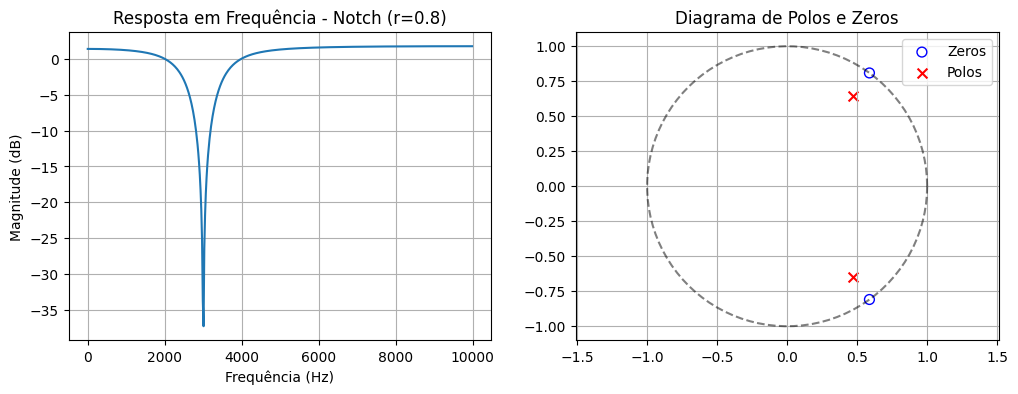

--- Análise para r = 0.9 ---


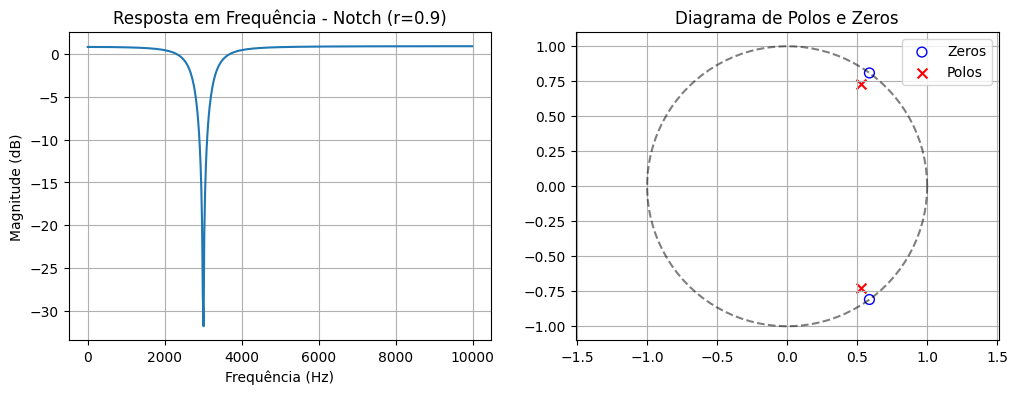

--- Análise para r = 0.99 ---


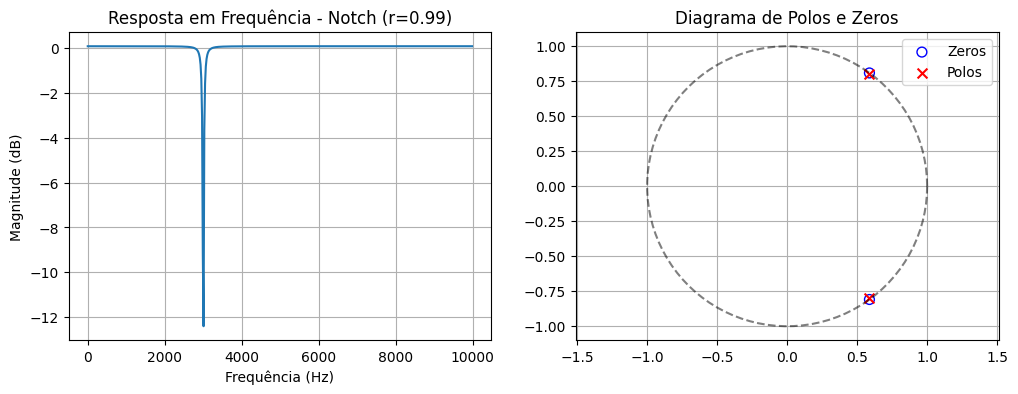

In [5]:
fc = 3000
theta = 2 * np.pi * fc / fs
for r in [0.8, 0.9, 0.99]:
    # Zeros sobre o círculo unitário na freq de rejeição
    b = [1, -2 * np.cos(theta), 1]
    a = [1, -2 * r * np.cos(theta), r**2]
    print(f'--- Análise para r = {r} ---')
    plot_filter_analysis(b, a, r, "Notch")

**Comentários sobre os resultados (1d):**
- **Seletividade:** O "entalhe" (notch) torna-se extremamente fino para $r=0.99$, permitindo remover uma frequência específica sem afetar as vizinhas.
- **Estabilidade:** Os zeros estão exatamente sobre o círculo unitário (rejeição infinita teórica), enquanto os polos internos garantem a estabilidade.
- **Largura de Banda:** Quanto maior o $r$, menor a largura de banda da rejeição, preservando melhor o restante do espectro do sinal.